In [2]:
import os
import sys
import logging
import random
import numpy as np

# Keep Kaggle output readable while TensorFlow initializes.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.FATAL)

import tensorflow as tf

# Fixed seeds make the comparison as reproducible as practical.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
# -----------------------------------------------------------------------------
# REPOSITORY CONFIGURATION
# -----------------------------------------------------------------------------
REPO_NAME = "RefraScan"
GITHUB_USER = "KyziaPi"
BRANCH_NAME = "Model-Experiment"  # Change to the branch containing the finalized VSCode code.
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"
REPO_PATH = os.path.join("/kaggle/working", REPO_NAME)

if not os.path.exists(REPO_PATH):
    !env GIT_TERMINAL_PROMPT=0 git clone -b {BRANCH_NAME} {REPO_URL}
else:
    !cd {REPO_PATH} && env GIT_TERMINAL_PROMPT=0 git fetch --all && git checkout {BRANCH_NAME} && git pull origin {BRANCH_NAME}

if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

import sys
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from src.preprocessing import load_and_clean_data, encode_target, validate_dataset
from src.cross_validation import (
    split_holdout_test,
    run_cross_validation,
    train_final_on_development,
    evaluate_holdout_once,
)
from src.models import build_model


Fetching origin
Already on 'Model-Experiment'
Your branch is up to date with 'origin/Model-Experiment'.
From https://github.com/KyziaPi/RefraScan
 * branch            Model-Experiment -> FETCH_HEAD
Already up to date.


In [4]:
# -----------------------------------------------------------------------------
# FINAL EXPERIMENT CONFIGURATION
# -----------------------------------------------------------------------------
# Set this ONLY after comparing EfficientNetB3, ResNet50, and DenseNet121
# using their image-only 10-fold CV results.
BEST_MODEL_NAME = "resnet50"  # Change after the controlled comparison.

PREPROCESS_INPUT = {
    "efficientnet": efficientnet_preprocess,
    "resnet50": resnet_preprocess,
    "densenet121": densenet_preprocess,
}[BEST_MODEL_NAME]

DATASET_DIR = '/kaggle/input/datasets/yerikaelainegueco/fundus-images-with-refractive-values'
CSV_PATH = os.path.join(DATASET_DIR, 'RefraScan_dataset.csv')
IMG_DIR = os.path.join(DATASET_DIR, 'FundusImages')

df = load_and_clean_data(CSV_PATH, IMG_DIR)
df = validate_dataset(df, patient_col="ID", target_col="classification")
df = encode_target(df)

# Recreate the fixed 15% holdout using the same random seed.
development_df, holdout_df = split_holdout_test(
    df, patient_col="ID", target_col="classification_encoded", test_size=0.15
)

print(f"Selected architecture: {BEST_MODEL_NAME}")



DATASET VALIDATION

Total records       : 1,018
Unique patients     : 517
Missing patient IDs : 0
Missing labels      : 0
Duplicate rows      : 0

Class distribution:
classification
Myopia        660
Hyperopia     236
Emmetropia    122
Name: count, dtype: int64

Patients with multiple target classes: 50
These patients have different classifications between their eyes. This is allowed.

Example mixed-class patients:
 ID classification
  2     Emmetropia
  2         Myopia
  4     Emmetropia
  4      Hyperopia
  7     Emmetropia
  7         Myopia
 14         Myopia
 14     Emmetropia
 19     Emmetropia
 19      Hyperopia
 24      Hyperopia
 24     Emmetropia
 27     Emmetropia
 27         Myopia
 34     Emmetropia
 34      Hyperopia
 42     Emmetropia
 42         Myopia
 44         Myopia
 44      Hyperopia

Valid target classes confirmed:
['Emmetropia', 'Hyperopia', 'Myopia']

Target-derived refractive measurement columns detected:
  - sphere
  - cylinder
  - spherical_equivalent

The

In [ ]:
# Testing Cell
# -----------------------------------------------------------------------------
# PROGRESSIVE FINE-TUNING OF THE SELECTED IMAGE-ONLY ARCHITECTURE
# -----------------------------------------------------------------------------
# DEBUG RUN: 2 folds only.
# Stage 1: unfreeze the upper 10 non-BatchNorm layers.
# Stage 2: expand to the upper 30 non-BatchNorm layers.
# Both stages use the same folds and a low learning rate of 1e-5.

fine_tuned_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=2,  # DEBUG ONLY — restore to 10 for the final experiment
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=False,
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/fine_tuning_debug",
    fine_tune=True,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

fine_tuned_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/final_image_only_finetuned_cv_results_debug.csv",
    index=False,
)

In [5]:
# -----------------------------------------------------------------------------
# PROGRESSIVE FINE-TUNING OF THE SELECTED IMAGE-ONLY ARCHITECTURE
# -----------------------------------------------------------------------------
# Stage 1: unfreeze the upper 10 non-BatchNorm layers.
# Stage 2: expand to the upper 30 non-BatchNorm layers.
# Both stages use the same folds and a low learning rate of 1e-5.

fine_tuned_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=10,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=False,
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/fine_tuning",
    fine_tune=True,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

fine_tuned_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/final_image_only_finetuned_cv_results.csv",
    index=False,
)



PATIENT-LEVEL HOLDOUT SPLIT
Development records : 864
Holdout records     : 154
Development patients: 439
Holdout patients    : 78
Patient overlap     : 0

The holdout set is now untouched and will not be used for architecture/model selection.

RESNET50 | IMAGE ONLY
10-FOLD STRATIFIED GROUP CROSS-VALIDATION

--- Fold 1/10 ---


I0000 00:00:1786886075.656005     128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786886075.659215     128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
 2/49 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.2969 - loss: 0.7827  

I0000 00:00:1786886093.613213     211 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.4708 - loss: 0.8263
Epoch 1: val_loss improved from None to 0.43112, saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.weights.h5

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.weights.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 50s 752ms/step - accuracy: 0.5571 - loss: 0.6750 - val_accuracy: 0.7294 - val_loss: 0.4311
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6601 - loss: 0.4029
Epoch 2: val_loss improved from 0.43112 to 0.36614, saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.weights.h5

Epoch 2: finished saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.weights.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 371ms/step - accuracy: 0.6418 - loss: 0.4578 - val_accuracy: 0.7176 - val_loss: 0.3661
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/s

In [ ]:
# Testing Cell
# -----------------------------------------------------------------------------
# ABLATION: FUNDUS IMAGE ONLY VS FUNDUS IMAGE + AGE
# -----------------------------------------------------------------------------
# DEBUG RUN: 2 folds only.
# Age is the ONLY additional feature tested here.
# Sphere, cylinder, and spherical equivalent remain excluded because they
# determine the refractive-error target.

age_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=2,  # DEBUG ONLY — restore to 10 for final experiment
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=True,
    metadata_cols=["age_scaled"],
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/age_ablation_debug",
    fine_tune=False,
)

age_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/image_plus_age_cv_results_debug.csv",
    index=False,
)

print(
    "\nDEBUG RUN: Compare the Macro F1 and balanced accuracy means "
    "to verify the pipeline completes correctly."
)

In [6]:
# -----------------------------------------------------------------------------
# ABLATION: FUNDUS IMAGE ONLY VS FUNDUS IMAGE + AGE
# -----------------------------------------------------------------------------
# Age is the ONLY additional feature tested here.
# Sphere, cylinder, and spherical equivalent remain excluded because they
# determine the refractive-error target.

age_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=10,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=True,
    metadata_cols=["age_scaled"],
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/age_ablation",
    fine_tune=False,
)

age_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/image_plus_age_cv_results.csv",
    index=False,
)

print("\nCompare the Macro F1 and balanced accuracy means above before choosing the final configuration.")


PATIENT-LEVEL HOLDOUT SPLIT
Development records : 864
Holdout records     : 154
Development patients: 439
Holdout patients    : 78
Patient overlap     : 0

The holdout set is now untouched and will not be used for architecture/model selection.

RESNET50 | IMAGE + AGE
10-FOLD STRATIFIED GROUP CROSS-VALIDATION

--- Fold 1/10 ---
Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5074 - loss: 0.8377
Epoch 1: val_loss improved from None to 0.52157, saving model to /kaggle/working/RefraScan/artifacts/age_ablation/resnet50_age_fold_1_frozen.weights.h5

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/age_ablation/resnet50_age_fold_1_frozen.weights.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 606ms/step - accuracy: 0.5892 - loss: 0.6380 - val_accuracy: 0.5882 - val_loss: 0.5216
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.5939 - loss: 0.5257
Epoch 2: val_loss improved from 0.52157 to 0.46290, saving model to /kaggle/working/RefraScan/artifacts/ag

In [7]:
# -----------------------------------------------------------------------------
# FINAL TRAINING ON ALL 85% DEVELOPMENT DATA
# -----------------------------------------------------------------------------
# At this point the architecture and feature configuration have already been
# selected using development-data CV. The 15% holdout remains untouched.

USE_AGE = False  # Set True only if the image+age ablation is the selected final configuration.
METADATA_COLS = ["age_scaled"] if USE_AGE else None

final_model, final_history = train_final_on_development(
    development_df=development_df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS,
    output_path=f"/kaggle/working/{REPO_NAME}/artifacts/final_model.weights.h5",
    fine_tune=True,
    fine_tune_layers=30,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

print("Final model trained using development data only.")


Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.4786 - loss: 0.8273
Epoch 1: saving model to /kaggle/working/RefraScan/artifacts/final_model.weights.h5

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.5660 - loss: 0.6572
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6509 - loss: 0.4667
Epoch 2: saving model to /kaggle/working/RefraScan/artifacts/final_model.weights.h5

Epoch 2: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 350ms/step - accuracy: 0.6458 - loss: 0.4418
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.6905 - loss: 0.3825
Epoch 3: saving model to /kaggle/working/RefraScan/artifacts/final_model.weights.h5

Epoch 3: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 342ms/step - accuracy: 0.

In [8]:
# -----------------------------------------------------------------------------
# FINAL HOLDOUT EVALUATION -- RUN THIS CELL ONCE
# -----------------------------------------------------------------------------
# Do NOT rerun this evaluation to make additional architecture/hyperparameter
# decisions. The holdout is the final unbiased estimate.
if USE_AGE:
    import joblib
    age_scaler = joblib.load(
        f"/kaggle/working/{REPO_NAME}/artifacts/final_model_age_scaler.pkl"
    )
    holdout_df["age_scaled"] = age_scaler.transform(holdout_df[["age"]])

final_holdout_result = evaluate_holdout_once(
    model=final_model,
    holdout_df=holdout_df,
    preprocess_input=PREPROCESS_INPUT,
    batch_size=16,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS,
    model_name=BEST_MODEL_NAME,
)



--- Running Inference ---

--- Classification Report ---
              precision    recall  f1-score   support

  Emmetropia       0.41      0.41      0.41        27
      Myopia       0.86      0.75      0.80        88
   Hyperopia       0.54      0.69      0.61        39

    accuracy                           0.68       154
   macro avg       0.60      0.62      0.60       154
weighted avg       0.70      0.68      0.68       154

--- Evaluation Metrics ---
Accuracy          : 0.6753
Balanced Accuracy : 0.6166
Macro Precision   : 0.6015
Macro Recall      : 0.6166
Macro F1          : 0.6047

Confusion Matrix:
[[11  5 11]
 [10 66 12]
 [ 6  6 27]]

*** FINAL HOLDOUT EVALUATION COMPLETED ONCE ***


Selected Grad-CAM indices: [1, 11, 12, 3, 2, 0]
Model input shape: (1, 224, 224, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['image_input']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


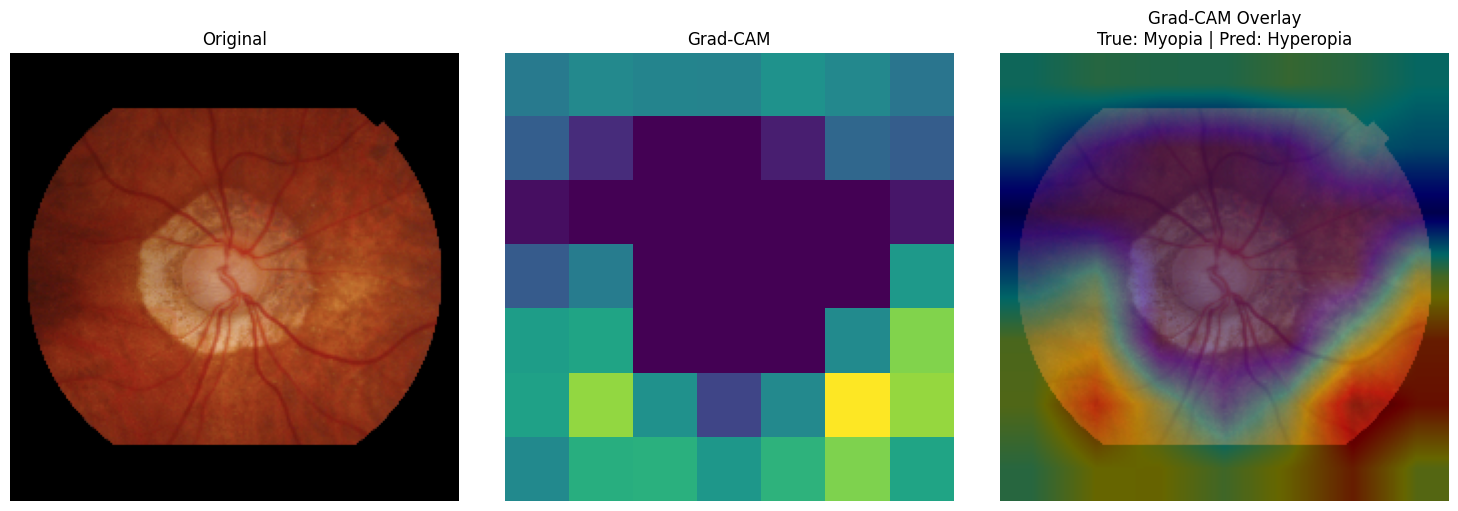

Model input shape: (1, 224, 224, 3)


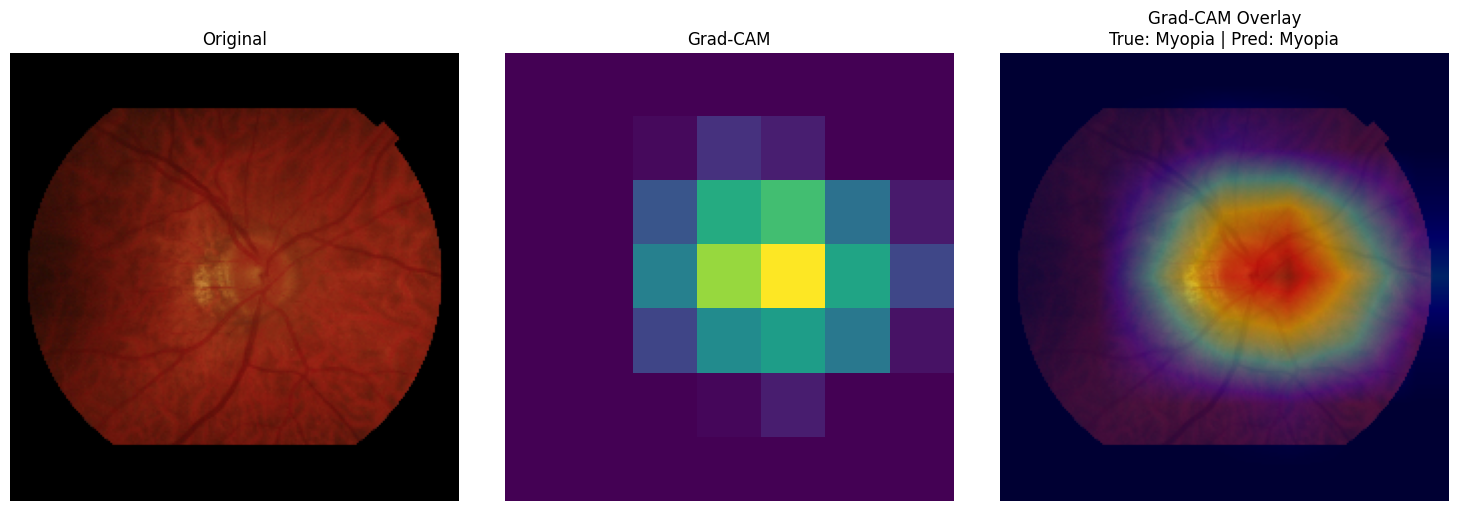

Model input shape: (1, 224, 224, 3)


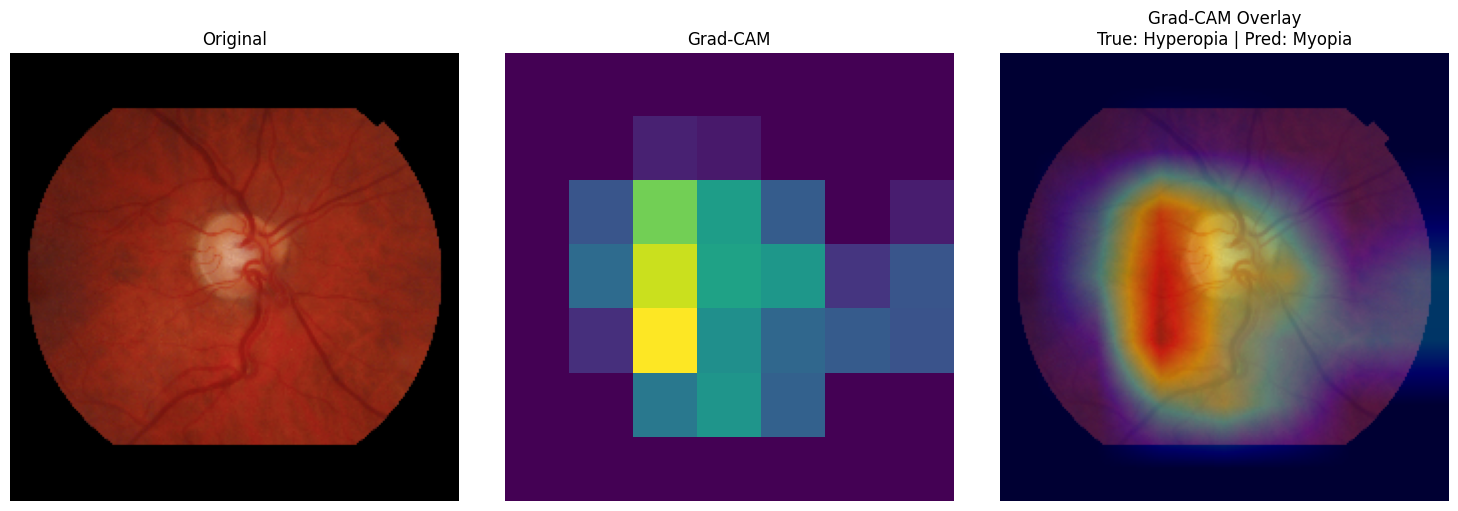

Model input shape: (1, 224, 224, 3)


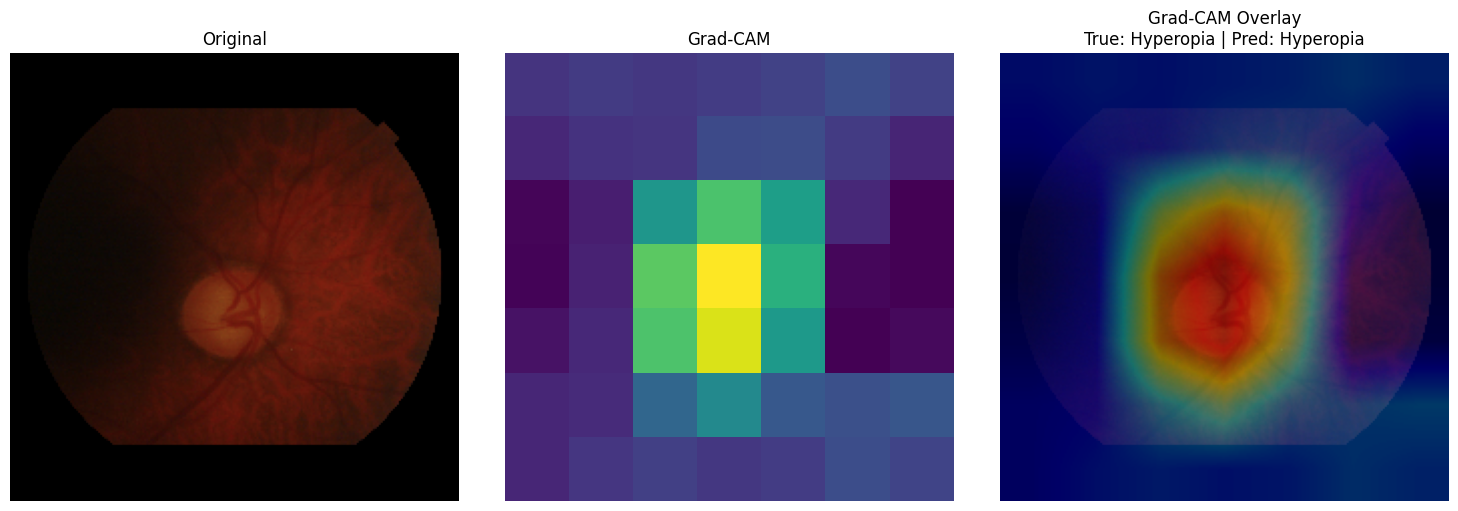

Model input shape: (1, 224, 224, 3)


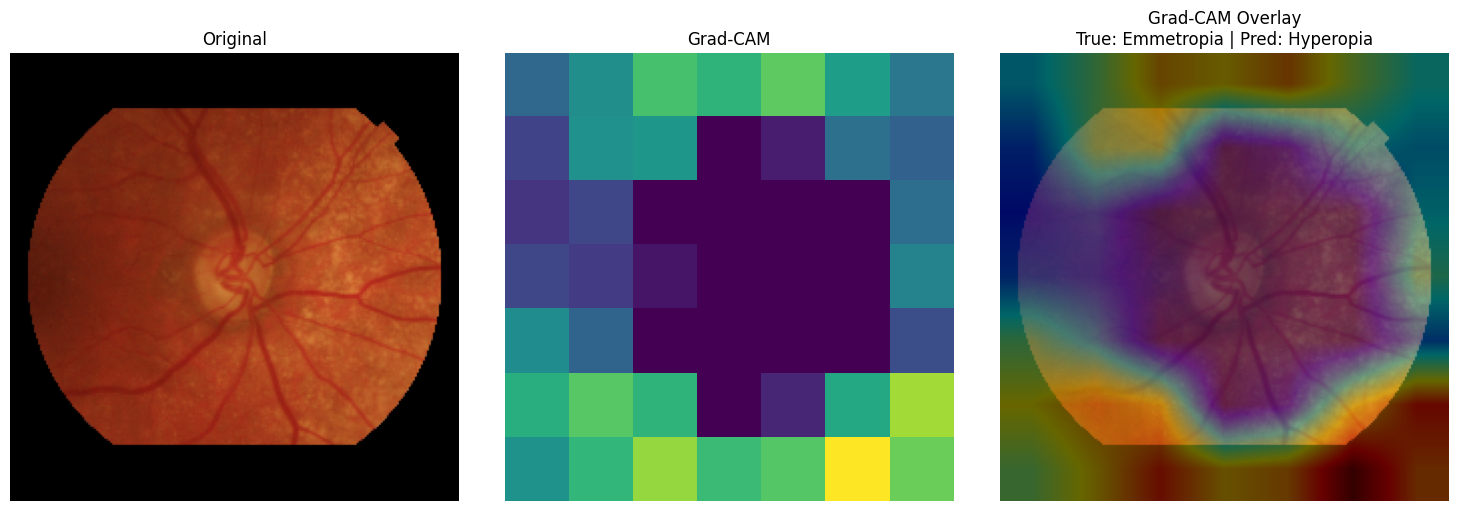

Model input shape: (1, 224, 224, 3)


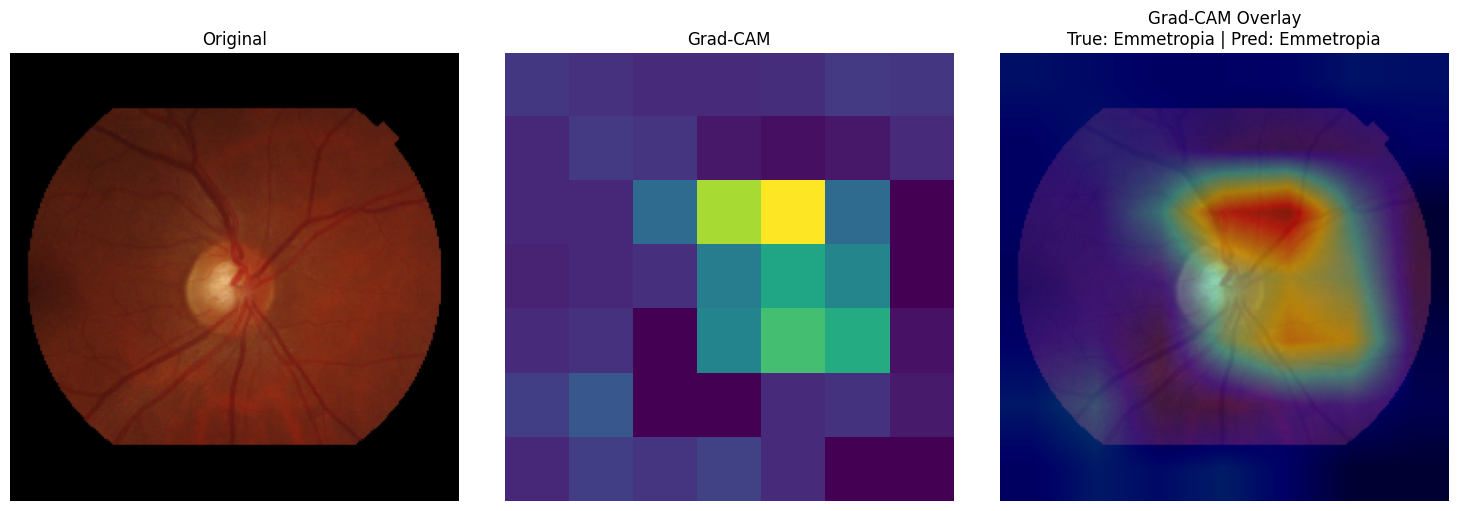

In [9]:
# -----------------------------------------------------------------------------
# GRAD-CAM: REPRESENTATIVE CORRECT / INCORRECT CASES
# -----------------------------------------------------------------------------
# The final holdout predictions are already stored in final_holdout_result, so
# this section does not perform another metric evaluation.

from src.explainability import make_gradcam_heatmap, show_gradcam
from src.preprocessing import load_and_preprocess_image, CLASS_NAMES
from src.cross_validation import get_input_image_shape

y_true = final_holdout_result["y_true"]
y_pred = final_holdout_result["y_pred"]

# Prefer incorrect minority-class cases first, then correct minority-class cases.
selected_indices = []
for target_class in [1, 2, 0]:
    wrong = np.where((y_true == target_class) & (y_pred != target_class))[0]
    right = np.where((y_true == target_class) & (y_pred == target_class))[0]
    if len(wrong):
        selected_indices.append(int(wrong[0]))
    if len(right):
        selected_indices.append(int(right[0]))

print("Selected Grad-CAM indices:", selected_indices)

for idx in selected_indices:
    row = holdout_df.iloc[idx]

    original = load_and_preprocess_image(
        row["full_path"],
        target_size=get_input_image_shape(BEST_MODEL_NAME)[:2],
    )

    model_image = PREPROCESS_INPUT(
        original.astype(np.float32)
    )[None, ...]

    metadata = None
    if USE_AGE:
        metadata = np.asarray(
            [[row["age_scaled"]]],
            dtype=np.float32
        )

    print("Model input shape:", model_image.shape)

    heatmap, explained_class = make_gradcam_heatmap(
        final_model,
        model_image,
        metadata=metadata,
        class_index=int(y_pred[idx]),
    )

    show_gradcam(
        original,
        heatmap,
        true_class=int(y_true[idx]),
        predicted_class=int(y_pred[idx]),
    )